In [1]:
import sys
print(sys.version)

3.13.7 | packaged by Anaconda, Inc. | (main, Sep  9 2025, 19:54:17) [Clang 17.0.6 ]


In [2]:
import sys
import os
# Get the current working directory
current_dir = '/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/' #os.getcwd()
print(current_dir)

# Add the src directory to the Python path
src_path = os.path.join(os.path.dirname(current_dir), 'src')
if src_path not in sys.path:
    sys.path.append(src_path)

import numpy as np
import matplotlib.pyplot as plt
import random
import cv2
from GridMetrics import GridScorer, circle_mask, get_even_odd_times, GridParameters, create_new_result_dir, load_grid_metrics_from_pickle
import json
import matplotlib
from matplotlib.lines import Line2D
import time

/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/


In [3]:
rat = 'r1'
mod = '3'
exp = 'OF'

general_results_working_directory = os.path.join(current_dir, 'results')
session_results_directory = create_new_result_dir(general_results_working_directory, rat+mod + '/Temporal shift')
G = GridParameters(rat, mod, exp, precompute=True)
print("keys:", G.__dict__.keys())

G.get_all_orientations_and_spacings()

G.save_class(session_results_directory)

Directory /Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/results/r13/Temporal shift already exists


/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/src/GridMetrics.py:387: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))


keys: dict_keys(['rat', 'mod', 'exp', 'delta', 'x', 'y', 'spikes', 'n_neurons', 'Scorer', 'grid_scores', 'mask_radius', 'orientation', 'spacing'])
Computing orientation of all cells
 Cell 1/149

/Users/wredman/Documents/GitHub/predictive-grid-cells/MEC data/src/GridMetrics.py:387: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))


 Cell 148/149Valid cells are 27 out of 149


In [4]:
delta_values = np.arange(-40, 40, 2)

# Create ONE GridParameters object
G = GridParameters(rat, mod, exp, precompute=False)

n_cells = len(G.spikes)
grid_scores = np.zeros((len(delta_values), n_cells))

for i, d in enumerate(delta_values):
    print(f"Computing delta = {d}")

    # Just change delta instead of rebuilding object
    G.delta = d

    for cell in range(n_cells):
        grid_scores[i, cell] = G.compute_cell_grid_score(cell)

results_save_path = session_results_directory
np.save(results_save_path + '/grid_scores.npy', grid_scores)


Computing delta = -40
Computing delta = -38
Computing delta = -36
Computing delta = -34
Computing delta = -32
Computing delta = -30
Computing delta = -28
Computing delta = -26
Computing delta = -24
Computing delta = -22
Computing delta = -20
Computing delta = -18
Computing delta = -16
Computing delta = -14
Computing delta = -12
Computing delta = -10
Computing delta = -8
Computing delta = -6
Computing delta = -4
Computing delta = -2
Computing delta = 0
Computing delta = 2
Computing delta = 4
Computing delta = 6
Computing delta = 8
Computing delta = 10
Computing delta = 12
Computing delta = 14
Computing delta = 16
Computing delta = 18
Computing delta = 20
Computing delta = 22
Computing delta = 24
Computing delta = 26
Computing delta = 28
Computing delta = 30
Computing delta = 32
Computing delta = 34
Computing delta = 36
Computing delta = 38


In [5]:
# best delta per cell (argmax across delta axis)
best_delta_idx = np.argmax(grid_scores, axis=0)
best_delta_values = delta_values[best_delta_idx]

print("best_delta_values defined, shape:", best_delta_values.shape)

best_delta_values defined, shape: (149,)


In [6]:
def circular_shift_xy(x, y, shift):
    """Circularly shift x and y by the same amount."""
    return np.roll(x, shift), np.roll(y, shift)

def compute_cell_gs_with_positions(G, cell, x_new, y_new, x_attr="x", y_attr="y"):
    """
    Compute grid score for one cell using TRUE spike times in G,
    but OVERRIDE positions with x_new/y_new temporarily.
    """
    x_orig = getattr(G, x_attr)
    y_orig = getattr(G, y_attr)

    setattr(G, x_attr, x_new)
    setattr(G, y_attr, y_new)
    setattr(G.Scorer, '_' + x_attr, x_new)
    setattr(G.Scorer, '_' + y_attr, y_new)
    gs = G.compute_cell_grid_score(cell)

    setattr(G, x_attr, x_orig)
    setattr(G, y_attr, y_orig)
    setattr(G.Scorer, '_' + x_attr, x_new)
    setattr(G.Scorer, '_' + y_attr, y_new)

    return gs

In [7]:
def run_shuffling_analysis(
    rat,
    mod,
    delta_values,
    grid_scores,
    n_shuffles=100,
    random_seed=0,
    x_attr="x",
    y_attr="y",
    progress_every=5,
):
    """
    Implements Dr. Redman's shuffling analysis.

    Steps:
    1) Use true grid scores to compute:
       GS0 per cell (delta=0) and GSmax per cell (max across deltas)
    2) Repeat n_shuffles times:
       - pick random circular shift 1..N-1
       - apply to positions x,y -> x_shuff,y_shuff
       - for each cell, compute shuffled GS using TRUE spikes + SHUFFLED positions
         at delta=0 and at each cell's best delta
    3) Count how many shuffled scores exceed GS0 and how many exceed GSmax
       Predictive if: count_exceed_GS0 > 5 AND count_exceed_GSmax < 5
    """
    rng = np.random.default_rng(random_seed)

    delta_values = np.asarray(delta_values)
    grid_scores = np.asarray(grid_scores)

    n_cells = grid_scores.shape[1]

    # True GS0 and GSmax per cell
    zero_idx = int(np.where(delta_values == 0)[0][0])
    gs0_true = grid_scores[zero_idx, :].copy()
    gsmax_true = np.max(grid_scores, axis=0).copy()

    # Build a delta=0 GridParameters object to get x,y and to compute GS with true spikes
    G0 = GridParameters(rat, mod, delta=0)

    # Pull position vectors
    x = np.asarray(getattr(G0, x_attr))
    y = np.asarray(getattr(G0, y_attr))
    N = len(x)
    if len(y) != N:
        raise ValueError("x and y must have the same length")

    # Storage: shuffled GS at delta=0 and at best-delta (per cell)
    gs0_shuff = np.zeros((n_shuffles, n_cells), dtype=float)

    t0 = time.time()
    print(f"Starting shuffles: {n_shuffles} shuffles, {n_cells} cells, N={N} position samples")

    for s in range(n_shuffles):
        shift = int(rng.integers(1, N))  # 1..N-1
        x_shuff, y_shuff = circular_shift_xy(x, y, shift)

        # delta=0 shuffled (reuse G0)
        for cell in range(n_cells):
            gs0_shuff[s, cell] = compute_cell_gs_with_positions(
                G0, cell, x_shuff, y_shuff, x_attr=x_attr, y_attr=y_attr
            )

        if (s + 1) % progress_every == 0:
            elapsed = time.time() - t0
            print(f"Shuffle {s+1}/{n_shuffles} done, elapsed {elapsed/60:.1f} min")

    # Counts per cell
    # shape trick: (n_shuffles, n_cells) > (1, n_cells) -> broadcast over rows
    counts_gt_gs0 = np.sum(gs0_shuff > gs0_true[None, :], axis=0)
    counts_gt_gsmax = np.sum(gs0_shuff > gsmax_true[None, :], axis=0)

    return {
        "gs0_true": gs0_true,
        "gsmax_true": gsmax_true,
        "gs0_shuff": gs0_shuff,
        "counts_gt_gs0": counts_gt_gs0,
        "counts_gt_gsmax": counts_gt_gsmax,
    }

In [8]:
results = run_shuffling_analysis(
    rat=rat,
    mod=mod,
    delta_values=delta_values,
    grid_scores=grid_scores,
    n_shuffles=100,
    random_seed=0,
    x_attr="x",
    y_attr="y",
    progress_every=5,
)

Starting shuffles: 100 shuffles, 149 cells, N=732099 position samples
Shuffle 5/100 done, elapsed 1.2 min
Shuffle 10/100 done, elapsed 2.3 min
Shuffle 15/100 done, elapsed 3.5 min
Shuffle 20/100 done, elapsed 4.6 min
Shuffle 25/100 done, elapsed 5.8 min
Shuffle 30/100 done, elapsed 6.9 min
Shuffle 35/100 done, elapsed 8.1 min
Shuffle 40/100 done, elapsed 9.3 min
Shuffle 45/100 done, elapsed 10.5 min
Shuffle 50/100 done, elapsed 11.7 min
Shuffle 55/100 done, elapsed 12.8 min
Shuffle 60/100 done, elapsed 14.0 min
Shuffle 65/100 done, elapsed 15.1 min
Shuffle 70/100 done, elapsed 16.2 min
Shuffle 75/100 done, elapsed 17.4 min
Shuffle 80/100 done, elapsed 18.5 min
Shuffle 85/100 done, elapsed 19.6 min
Shuffle 90/100 done, elapsed 20.8 min
Shuffle 95/100 done, elapsed 21.9 min
Shuffle 100/100 done, elapsed 23.0 min


In [9]:
# Classifying predictive grid cells
exceed_thresh = 5
grid_cell_thresh = 0.5
max_grid_score_min = 0.3

non_grid_cells = results['gs0_true'] < grid_cell_thresh # cells that are not "classic" grid cells
predictive_cells = best_delta_values < 0 # cells that have their best shift negative (i.e., best grid score is at a prospective shift)
above_chance_cells = results['counts_gt_gsmax'] < exceed_thresh # cells that have their max grid score greater than the shuffle distribution
griddy_shifted_cells = results['gsmax_true'] > max_grid_score_min # the maximum grid score at the shifted value is greater than a minimum value
predictive_grid_cells = (non_grid_cells & predictive_cells & above_chance_cells & griddy_shifted_cells)

print('# predictive grid cells / # non-grid cells:' + str(np.sum(predictive_grid_cells)) + '/' + str(np.sum(non_grid_cells)))
print('Predictive grid cell ids:' + str(np.argwhere(predictive_grid_cells == 1)[:, 0]))
print('Grid score at delta = 0:' + str(results['gs0_true'][predictive_grid_cells]))
print('Grid score at delta max:' + str(results['gsmax_true'][predictive_grid_cells]))

# predictive grid cells / # non-grid cells:16/111
Predictive grid cell ids:[ 19  35  36  37  42  48  55  73  75  83 103 107 108 115 121 143]
Grid score at delta = 0:[ 0.48538427  0.37598144  0.33227072  0.47845166  0.29626585 -0.19910469
  0.29159538  0.431108    0.43528958  0.46596366  0.49203619  0.01177164
  0.2238347   0.43329189  0.42243043  0.44651087]
Grid score at delta max:[0.5659126  0.40887919 0.43776529 0.54189175 0.42222147 0.30608817
 0.42086009 0.50316133 0.4460102  0.47049541 0.54802002 0.43520093
 0.64927945 0.51937274 0.44822076 0.52965102]


In [10]:
np.save(results_save_path + '/results.npy', results)
np.save(results_save_path + '/predictive_grid_cells.npy', predictive_grid_cells)
np.save(results_save_path + '/best_delta.npy', best_delta_values)
np.save(results_save_path + '/grid_scores.npy', grid_scores)

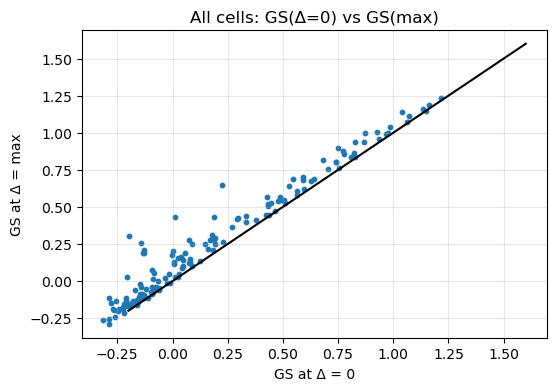

In [11]:
# GS at delta=0
idx0 = int(np.where(delta_values == 0)[0][0])
gs0 = grid_scores[idx0, :]

# GS(max) for each cell across deltas
gsmax = np.max(grid_scores, axis=0)

plt.figure(figsize=(6, 4))
plt.plot([-0.2, 1.6], [-0.2, 1.6], 'k-')
plt.scatter(gs0, gsmax, s=10)
plt.xlabel("GS at Δ = 0")
plt.ylabel("GS at Δ = max")
plt.title("All cells: GS(Δ=0) vs GS(max)")
plt.grid(alpha=0.3)
plt.savefig(results_save_path + '/GS_delta_0_vs_GS_delta_max.png')
plt.savefig(results_save_path + '/GS_delta_0_vs_GS_delta_max.svg', format = 'svg')
plt.show()

In [12]:
def plot_delta_curve(cell, delta_values, grid_scores):
    """
    Plot grid score as a function of delta for a given cell.
    """
    gs = grid_scores[:, cell]         # grid scores for this cell across deltas

    plt.figure(figsize=(10, 4))
    plt.plot(delta_values, gs, marker='o')
    plt.axhline(0, color='grey', linestyle='--', linewidth=1)

    plt.title(f'Cell {cell}: Grid Score vs Delta shift')
    plt.xlabel('Delta shift (time bins)')
    plt.ylabel('Grid Score')
    plt.grid(alpha=0.3)

    # Print maximum + which delta produced it
    best_idx = np.argmax(gs)
    print(f'Best grid score:' + str(gs[best_idx]) +  'at delta = ' + str(delta_values[best_idx]))

Best grid score:[0.5659126]at delta = -6


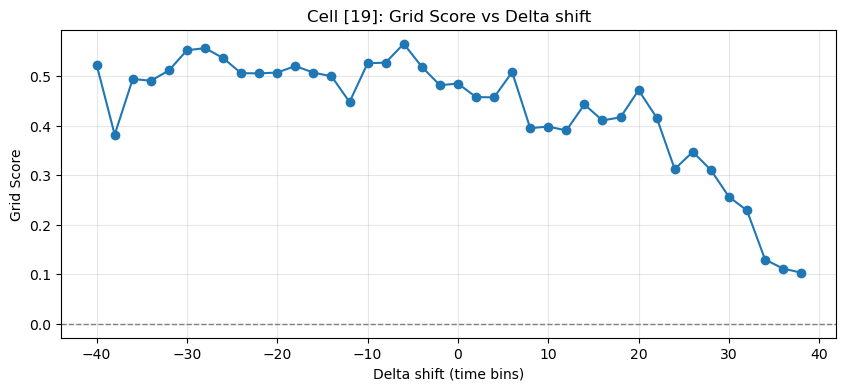

Best grid score:[0.40887919]at delta = -16


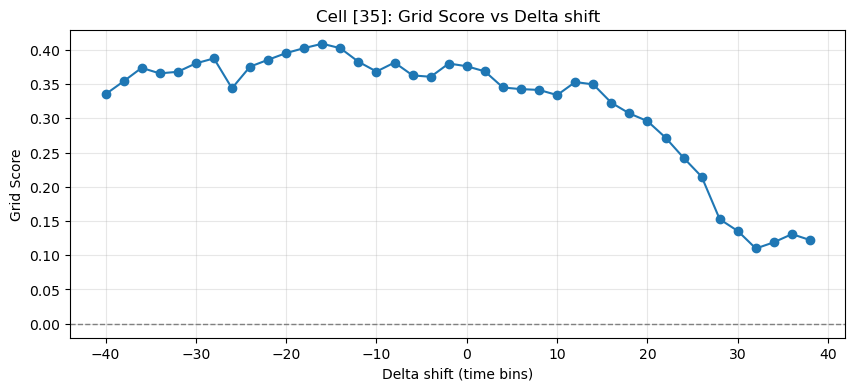

Best grid score:[0.43776529]at delta = -30


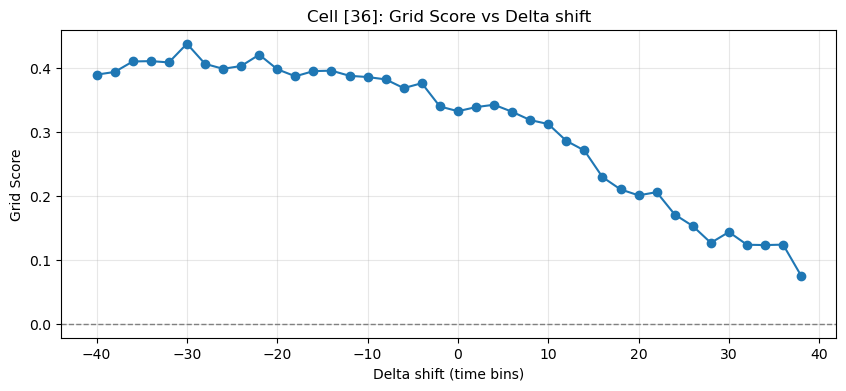

Best grid score:[0.54189175]at delta = -24


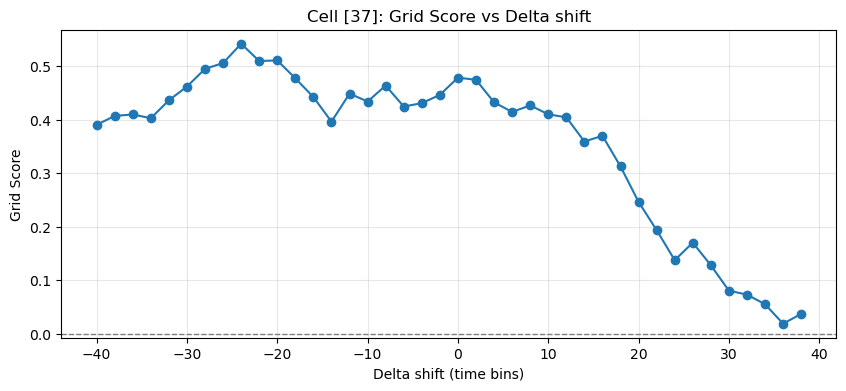

Best grid score:[0.42222147]at delta = -8


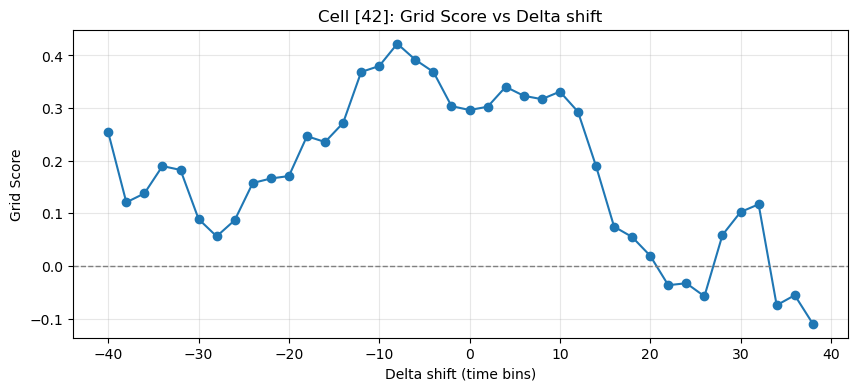

Best grid score:[0.30608817]at delta = -40


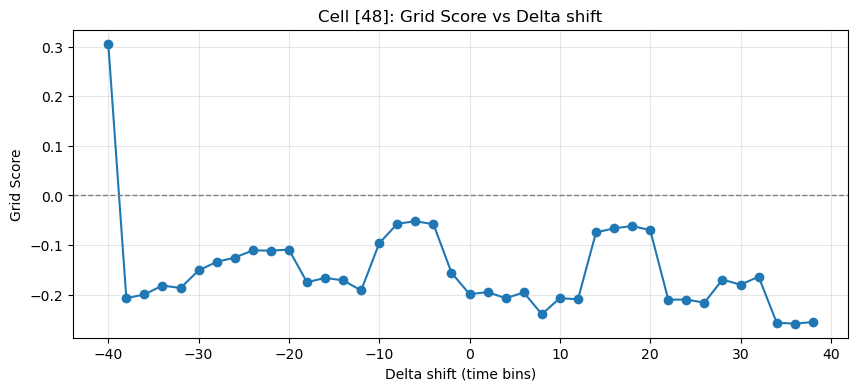

Best grid score:[0.42086009]at delta = -26


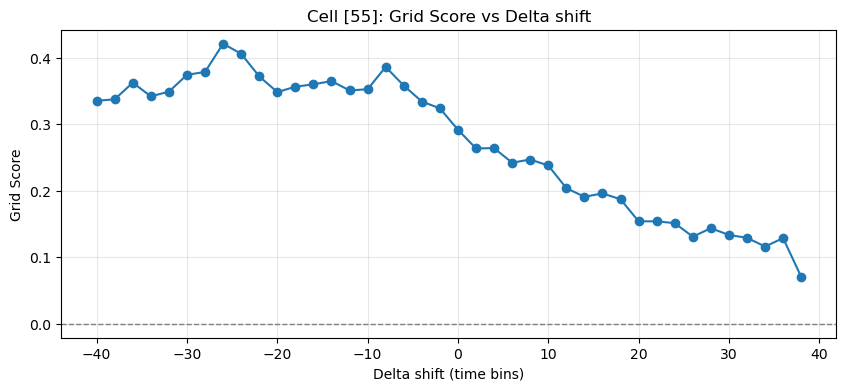

Best grid score:[0.50316133]at delta = -10


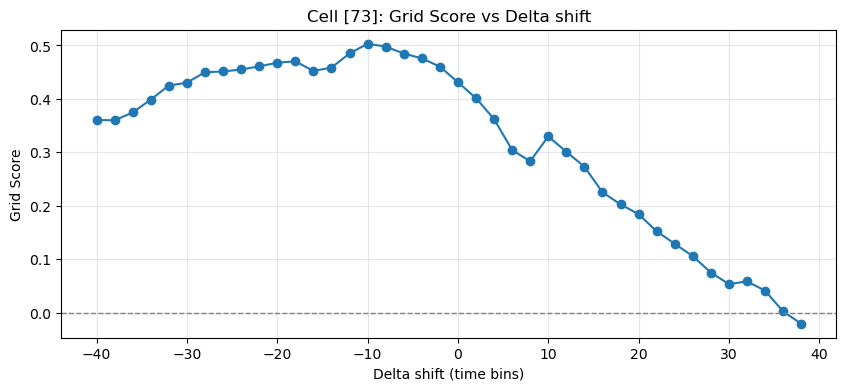

Best grid score:[0.4460102]at delta = -24


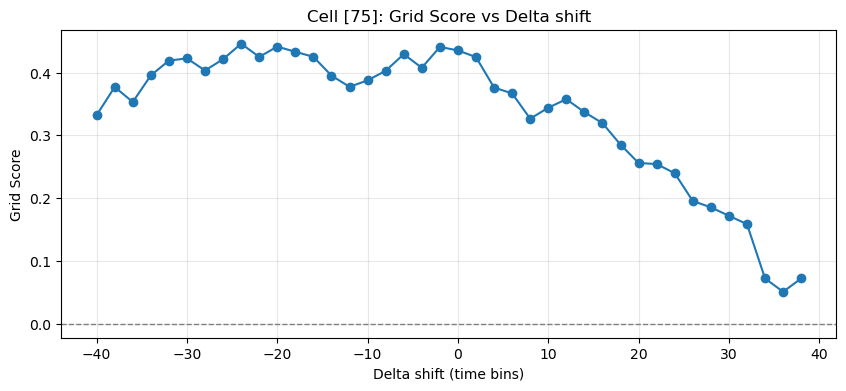

Best grid score:[0.47049541]at delta = -4


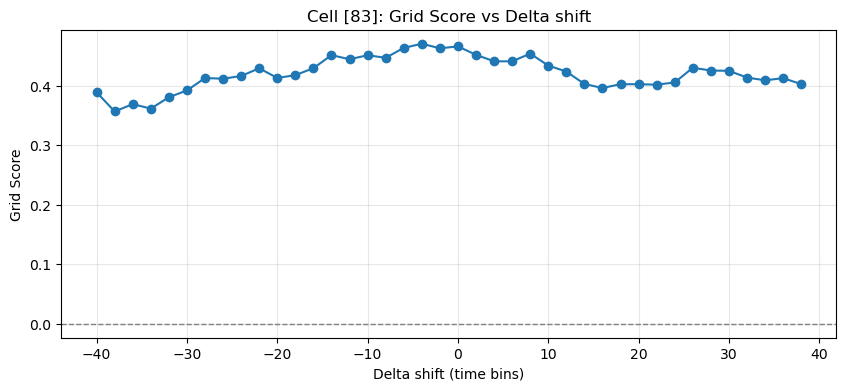

Best grid score:[0.54802002]at delta = -20


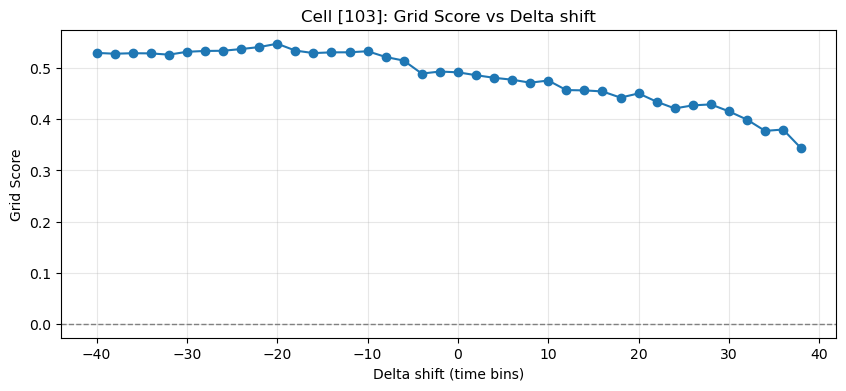

Best grid score:[0.43520093]at delta = -28


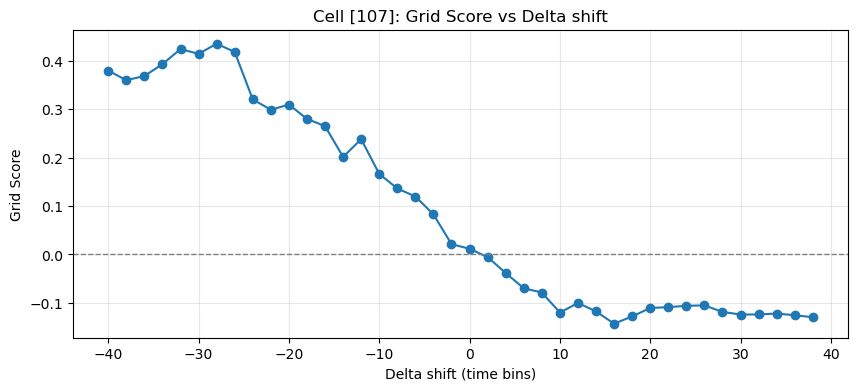

Best grid score:[0.64927945]at delta = -8


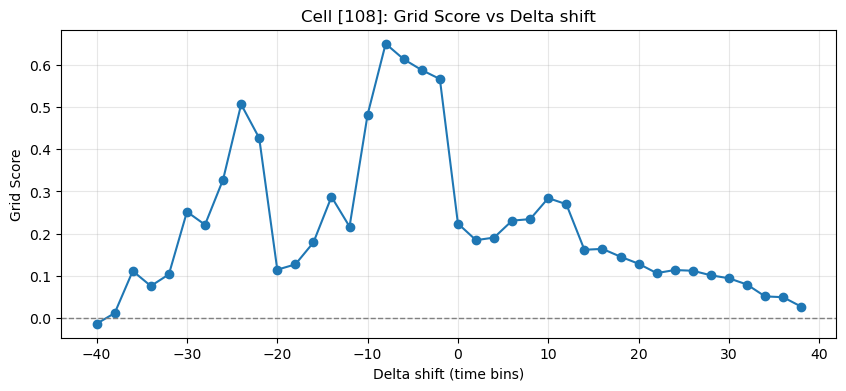

Best grid score:[0.51937274]at delta = -28


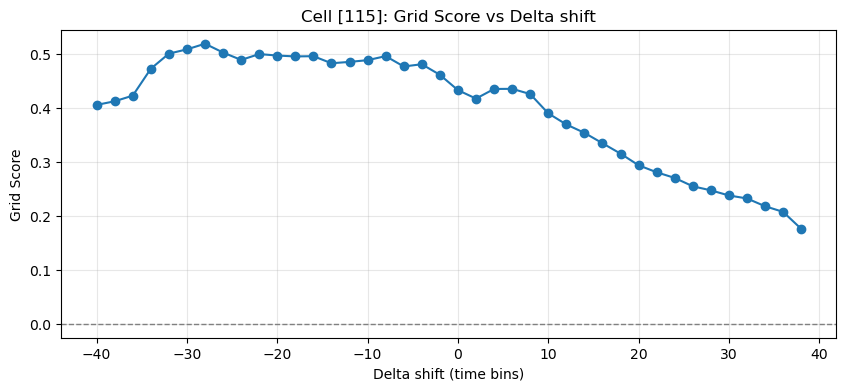

Best grid score:[0.44822076]at delta = -20


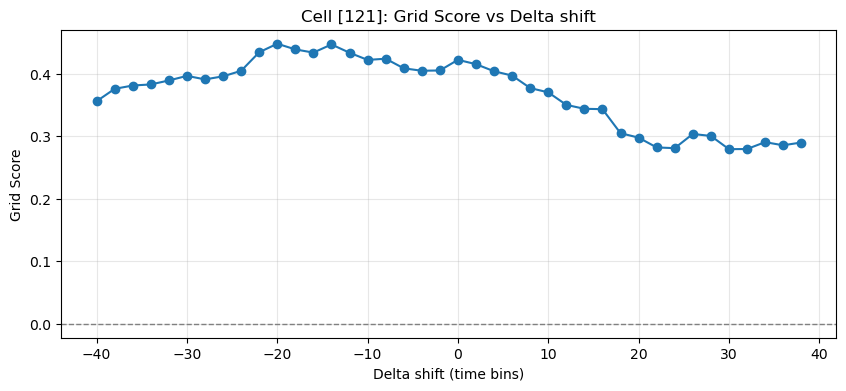

Best grid score:[0.52965102]at delta = -22


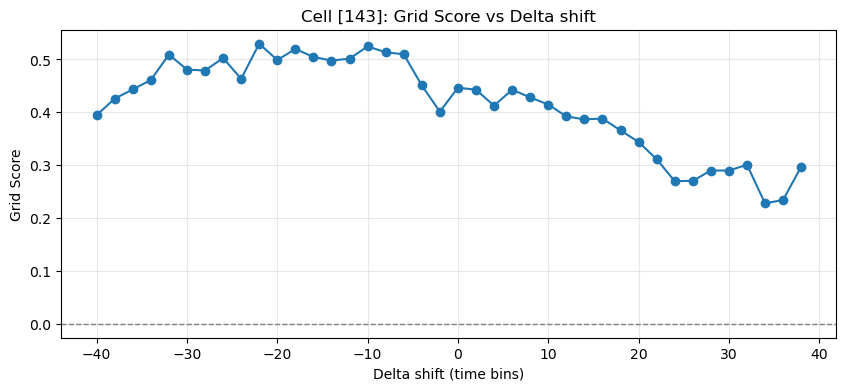

In [13]:
predictive_grid_cell_ids = np.argwhere(predictive_grid_cells == 1)
for ii in range(len(predictive_grid_cell_ids)):
    plot_delta_curve(predictive_grid_cell_ids[ii], delta_values, grid_scores)
    plt.savefig(results_save_path + '/Cell_' + str(predictive_grid_cell_ids[ii]) + '_delta_tuning_curve.png')
    plt.savefig(results_save_path + '/Cell_' + str(predictive_grid_cell_ids[ii]) + '_delta_tuning_curve.svg', format = 'svg')
    plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

def rgb_ratemap(im, cmap="jet", smooth=True):
    cm = plt.cm.get_cmap(cmap)

    np.seterr(invalid="ignore")
    im = np.array(im, dtype=float)
    im = np.nan_to_num(im, nan=0.0)

    visited = im > 0
    im2 = im.copy()
    im2[~visited] = np.nan

    mn = np.nanmin(im2)
    mx = np.nanmax(im2)

    if not np.isfinite(mn) or not np.isfinite(mx) or mx == mn:
        im01 = np.zeros_like(im, dtype=float)
    else:
        im01 = (im - mn) / (mx - mn)

    im01 = np.nan_to_num(im01, nan=0.0)
    im01 = np.clip(im01, 0.0, 1.0)

    if smooth and HAS_CV2:
        im01 = cv2.GaussianBlur(im01, (3, 3), sigmaX=1, sigmaY=0)

        if np.any(visited):
            mn2 = np.min(im01[visited])
            mx2 = np.max(im01[visited])
            if np.isfinite(mn2) and np.isfinite(mx2) and mx2 != mn2:
                im01 = (im01 - mn2) / (mx2 - mn2)
                im01 = np.clip(im01, 0.0, 1.0)

    rgb_img = cm(im01)[..., :3]
    rgb_img = (rgb_img * 255).astype(np.uint8)
    return rgb_img

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_28072/141904305.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cell = int(predictive_grid_cell_ids[ii])
/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_28072/2062097205.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm = plt.cm.get_cmap(cmap)


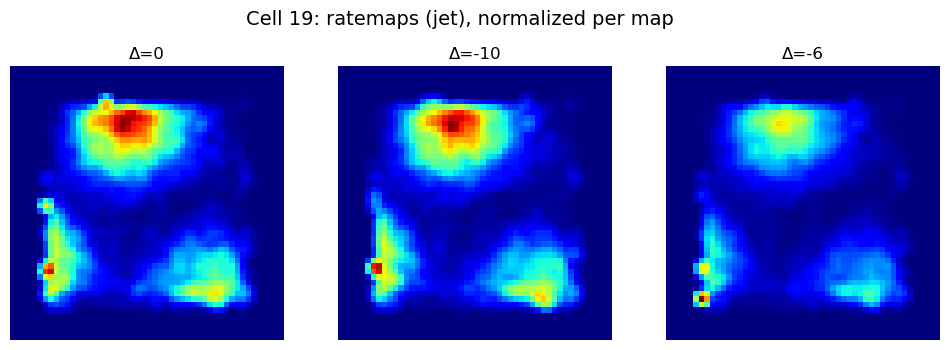

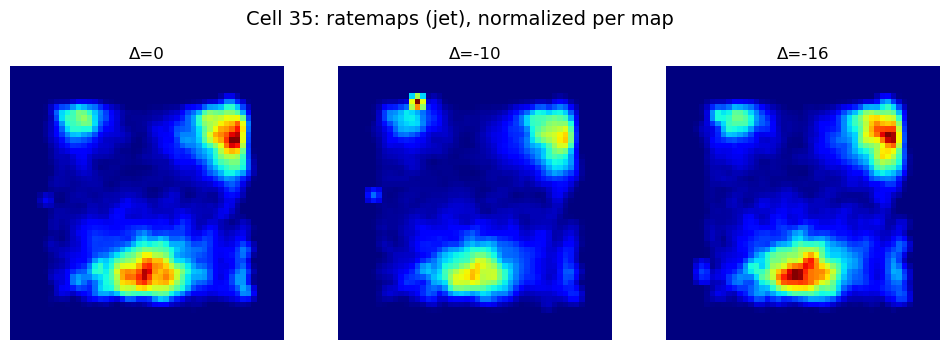

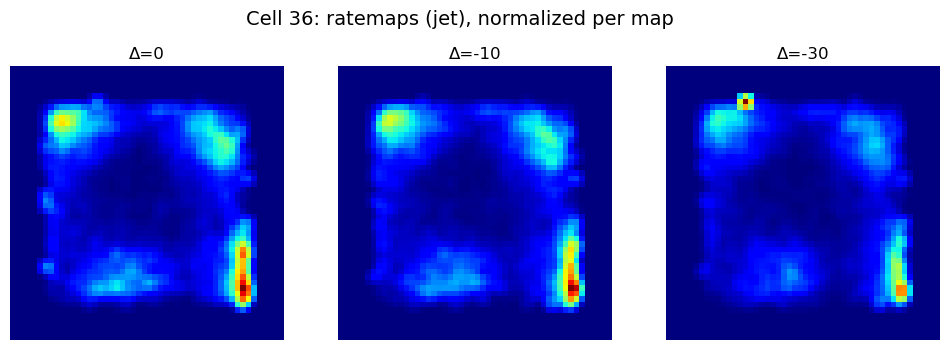

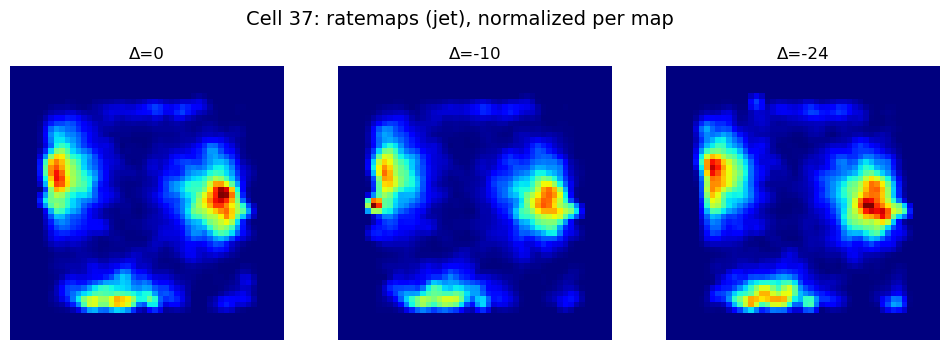

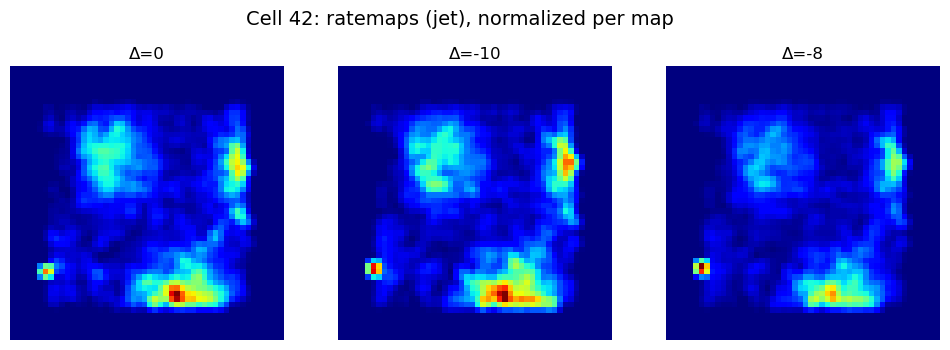

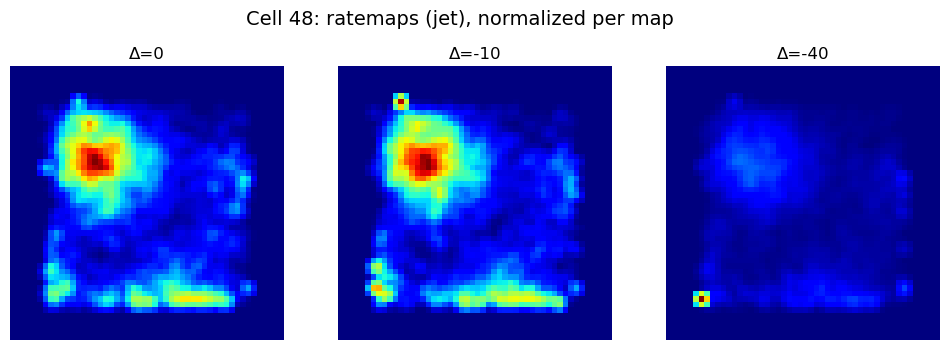

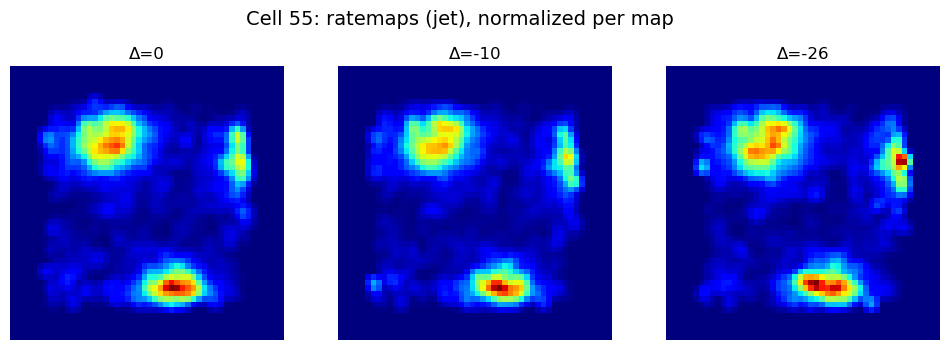

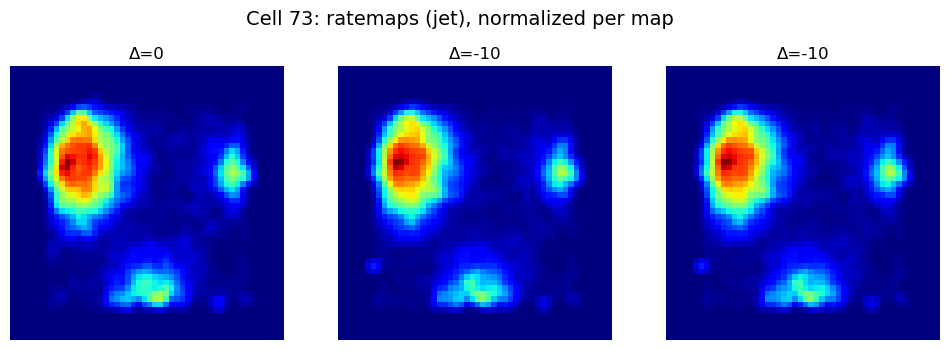

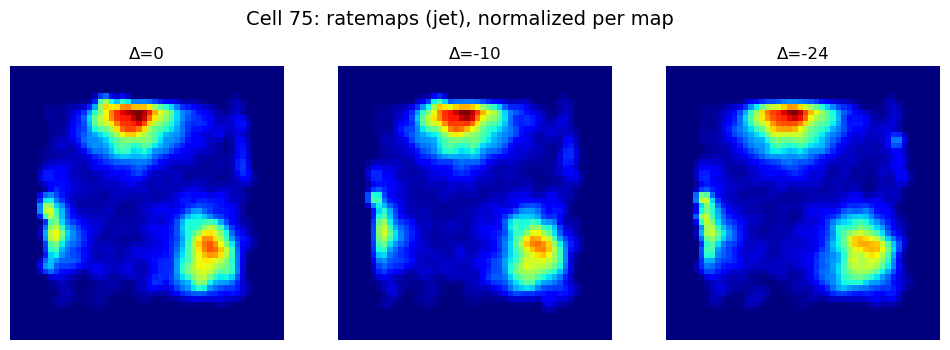

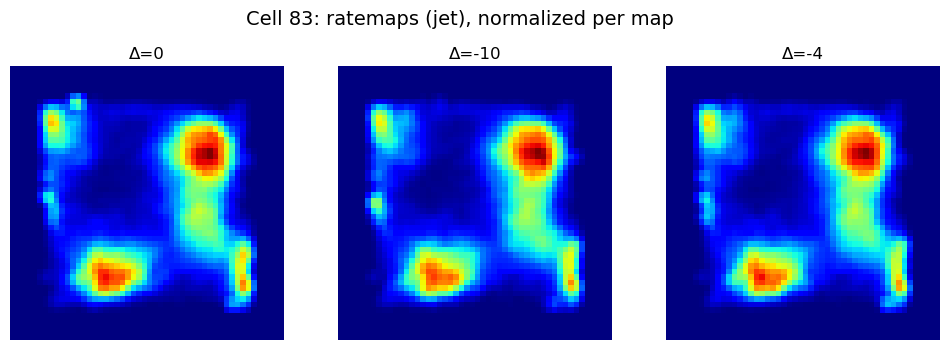

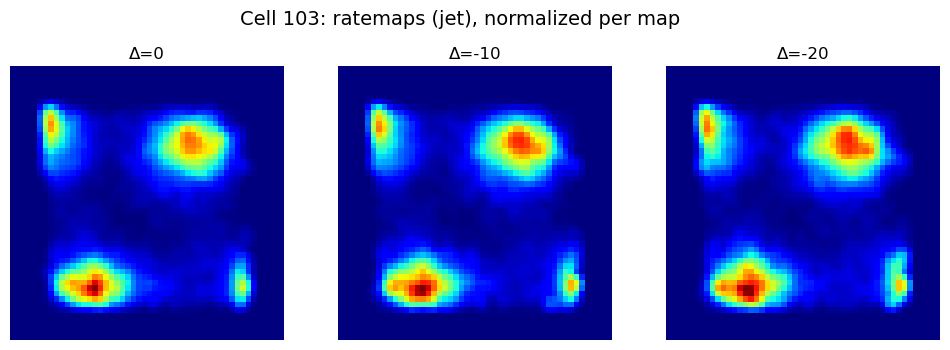

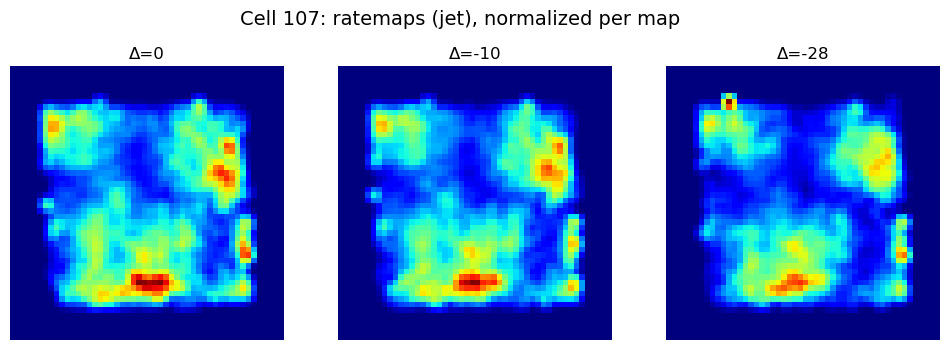

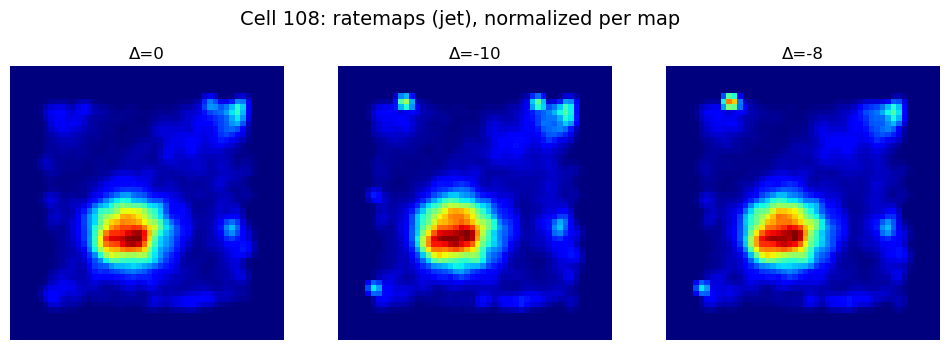

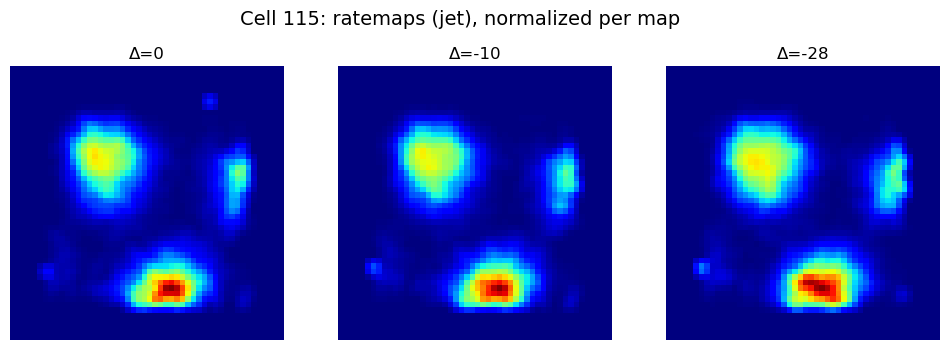

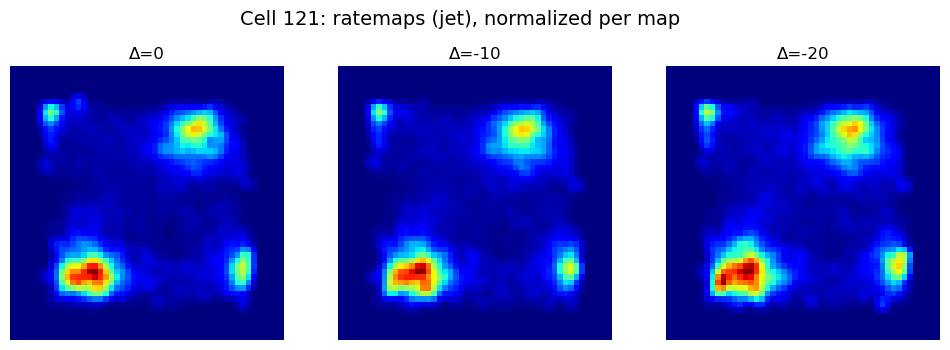

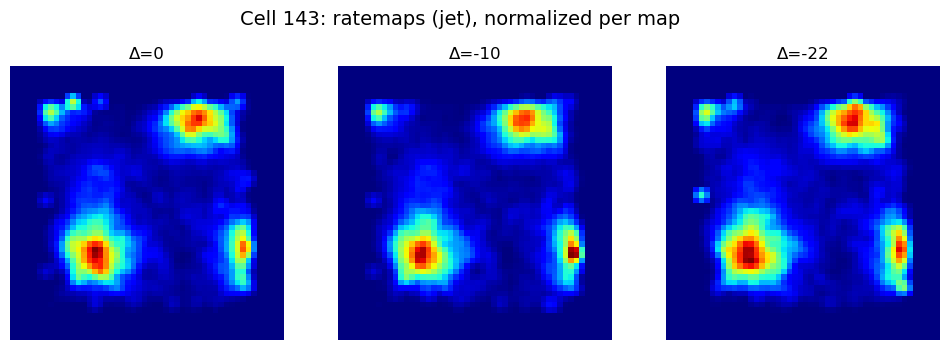

In [15]:
for ii in range(len(predictive_grid_cell_ids)):
    cell = int(predictive_grid_cell_ids[ii])

    G0 = GridParameters(rat, mod, delta=0.0)
    Gmid = GridParameters(rat, mod, delta=-10.0)

    best_idx = int(np.argmax(grid_scores[:, cell]))
    dbest = float(delta_values[best_idx])
    Gbest = GridParameters(rat, mod, delta=dbest)

    r0 = G0.Scorer.calculate_ratemap(cell=cell, delta=G0.delta)
    rmid = Gmid.Scorer.calculate_ratemap(cell=cell, delta=Gmid.delta)
    rbest = Gbest.Scorer.calculate_ratemap(cell=cell, delta=Gbest.delta)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    titles = ["Δ=0", "Δ=-10", f"Δ={int(dbest)}"]
    maps = [r0, rmid, rbest]

    for a, R, t in zip(ax, maps, titles):
        a.imshow(rgb_ratemap(R))
        a.set_title(t)
        a.axis("off")

    fig.suptitle(f"Cell {cell}: ratemaps (jet), normalized per map", fontsize=14)
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_normalized_rate_map.png')
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_normalized_rate_map.svg', format='svg')
    plt.show()

/var/folders/vc/hg24zlnx53l5v637yk9tlnx80000gn/T/ipykernel_28072/3870130736.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cell = int(predictive_grid_cell_ids[ii])


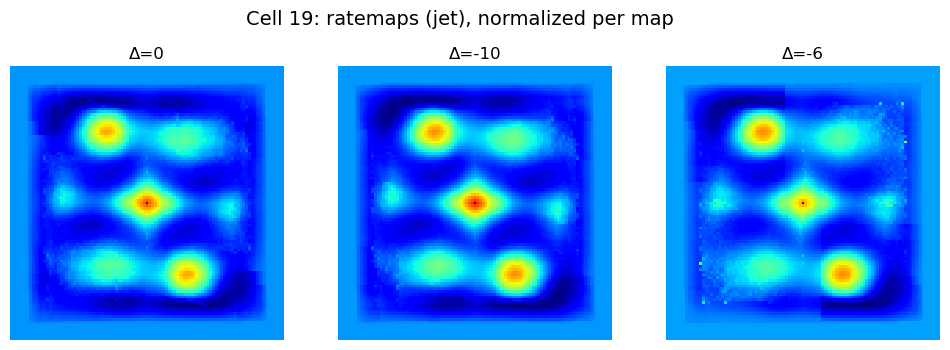

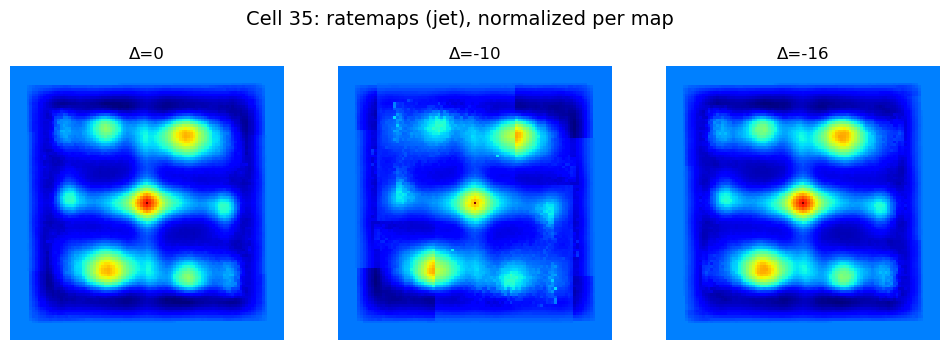

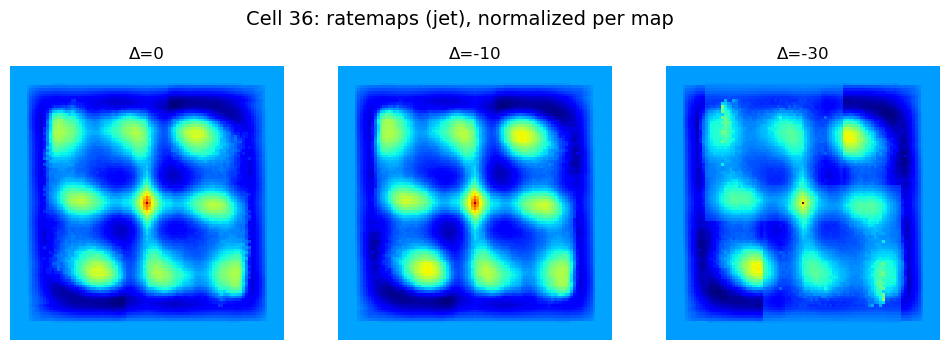

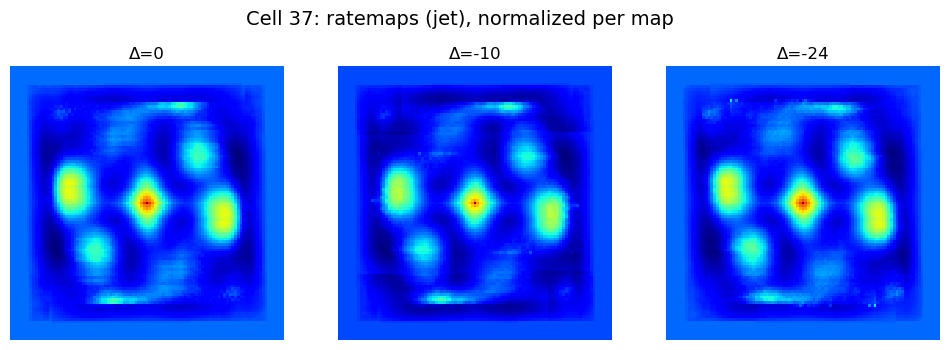

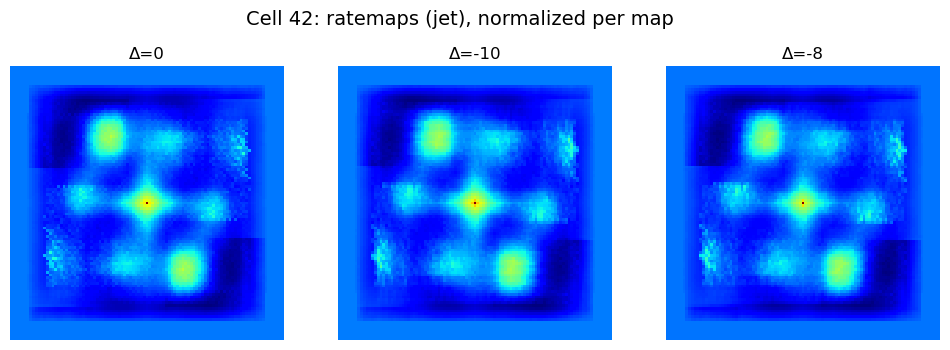

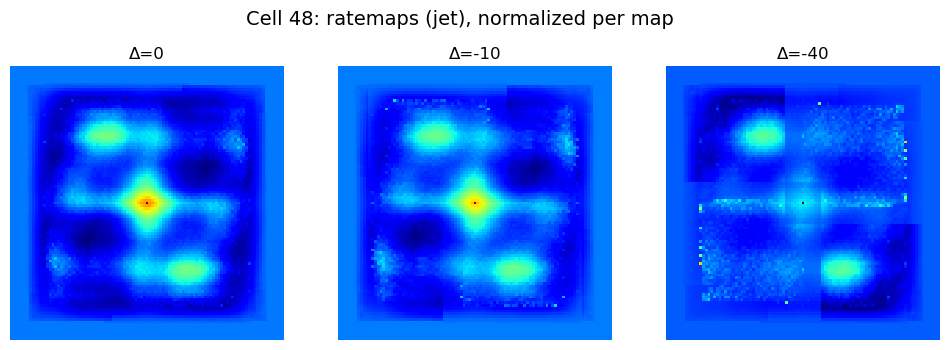

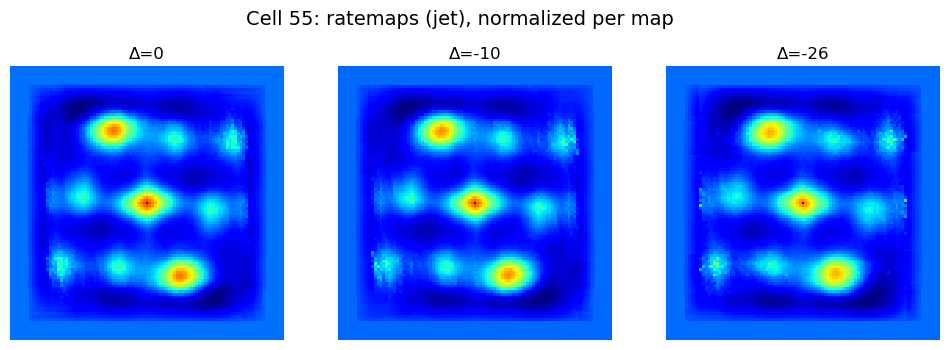

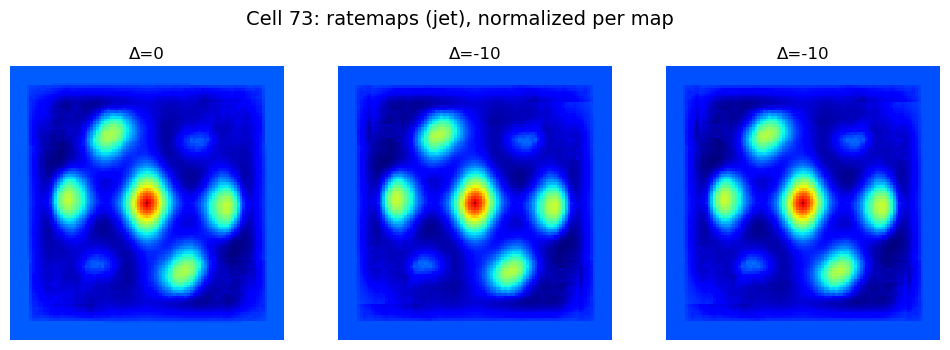

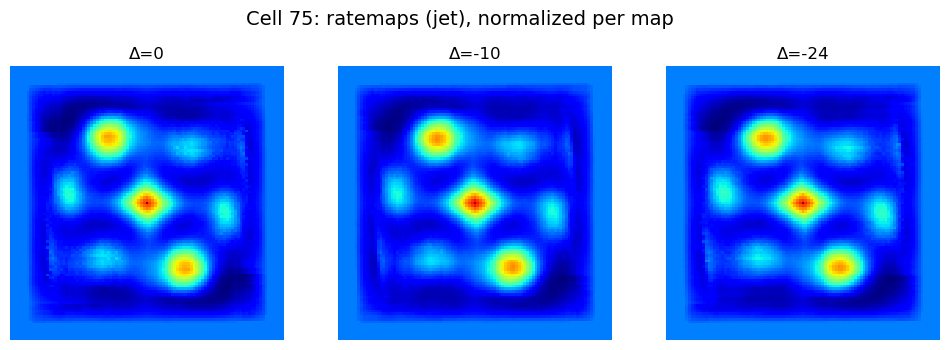

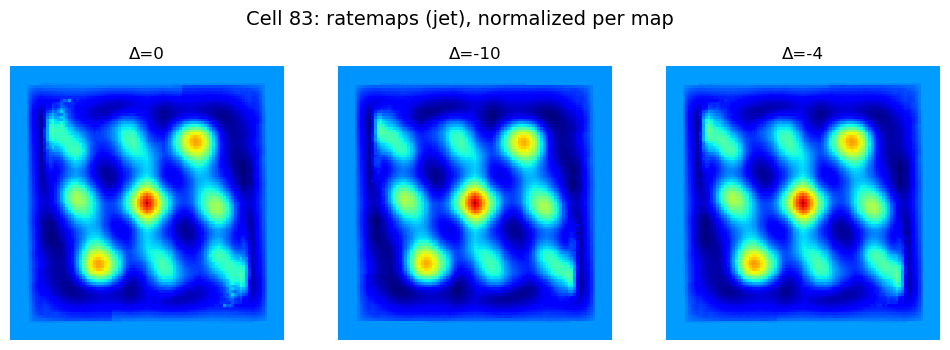

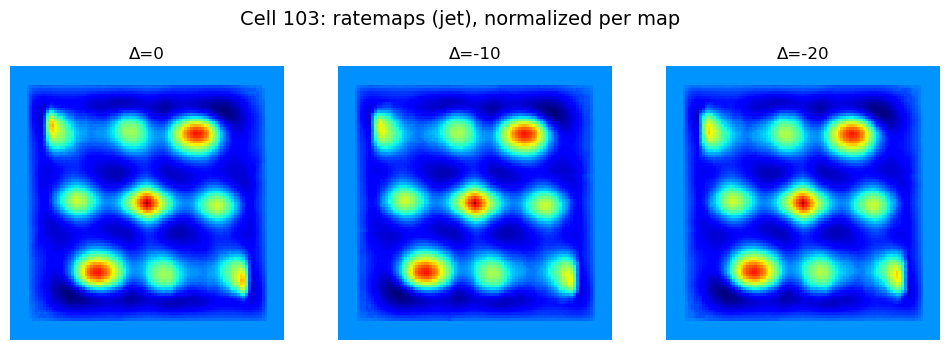

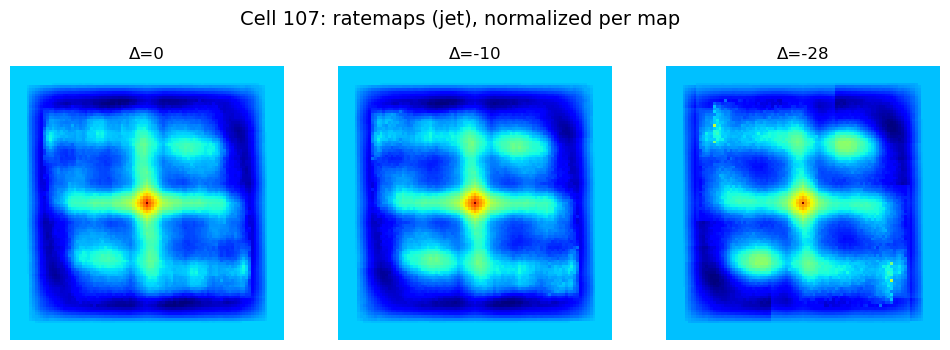

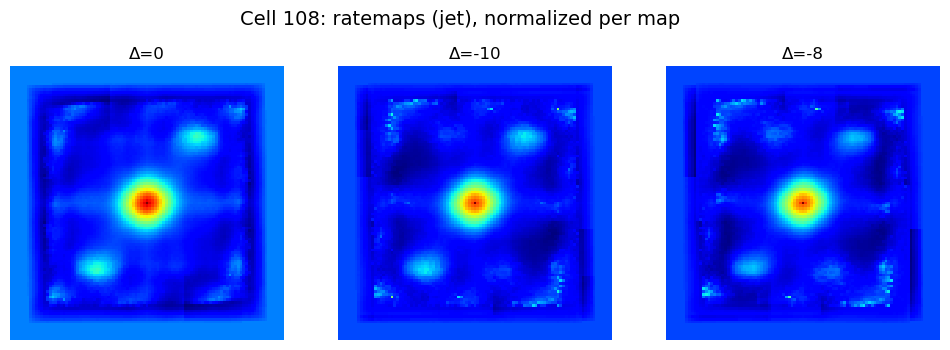

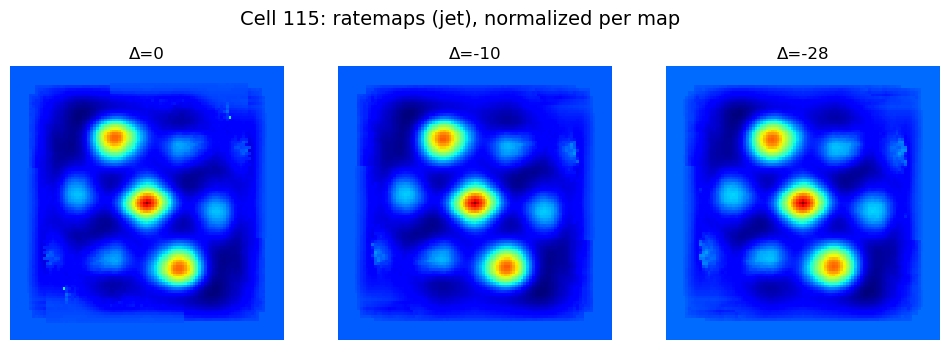

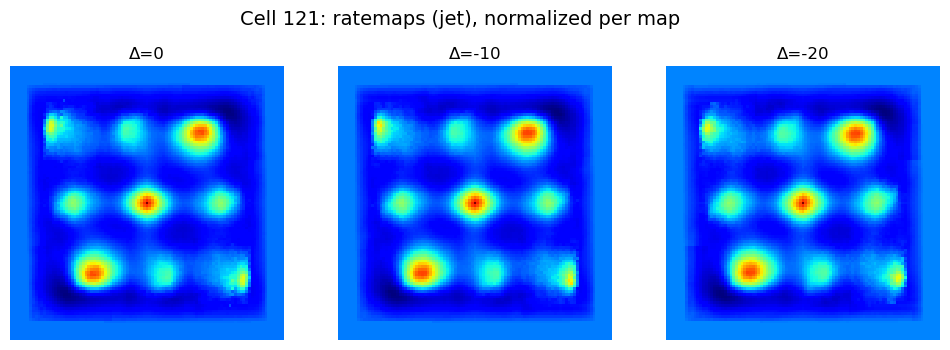

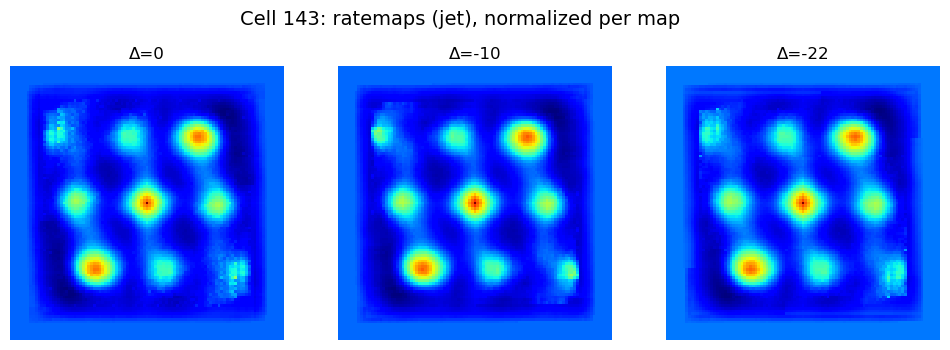

In [16]:
for ii in range(len(predictive_grid_cell_ids)):
    cell = int(predictive_grid_cell_ids[ii])

    G0 = GridParameters(rat, mod, delta=0.0)
    Gmid = GridParameters(rat, mod, delta=-10.0)

    best_idx = int(np.argmax(grid_scores[:, cell]))
    dbest = float(delta_values[best_idx])
    Gbest = GridParameters(rat, mod, delta=dbest)

    sac0    = G0.Scorer.calculate_sac(cell=cell, delta=G0.delta)
    sacmid  = Gmid.Scorer.calculate_sac(cell=cell, delta=Gmid.delta)
    sacbest = Gbest.Scorer.calculate_sac(cell=cell, delta=Gbest.delta)

    fig, ax = plt.subplots(1, 3, figsize=(12, 4))

    titles = ["Δ=0", "Δ=-10", f"Δ={int(dbest)}"]
    maps = [sac0, sacmid, sacbest]

    for a, R, t in zip(ax, maps, titles):
        a.imshow(R, interpolation='nearest', cmap = 'jet')
        a.set_title(t)
        a.axis("off")

    fig.suptitle(f"Cell {cell}: ratemaps (jet), normalized per map", fontsize=14)
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_SAC.png')
    plt.savefig(results_save_path + '/Cell_' + str(cell) + '_SAC.svg', format='svg')
    plt.show()


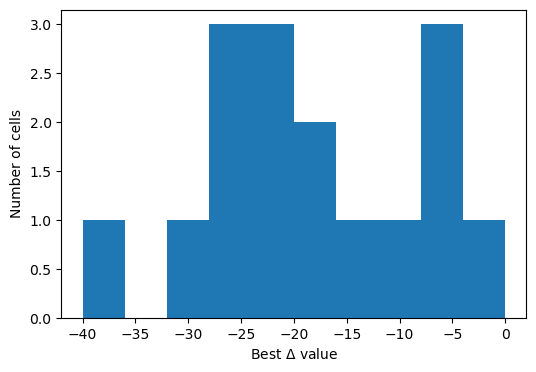

In [17]:
plt.figure(figsize = (6, 4))
plt.hist(best_delta_values[predictive_grid_cell_ids], bins = np.linspace(-40, 0, 11))
plt.xlabel('Best $\Delta$ value')
plt.ylabel('Number of cells')
plt.savefig(results_save_path + '/Best_delta_values.png')
plt.savefig(results_save_path + '/Best_delta_values.svg', format = 'svg')
plt.show()

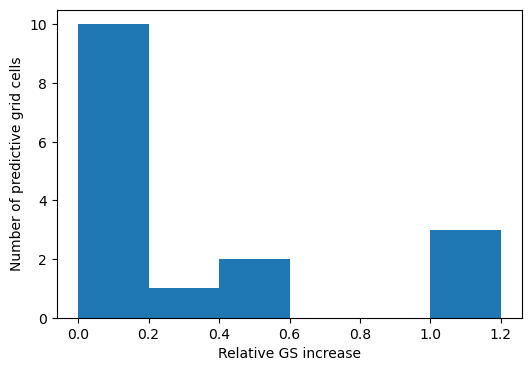

In [18]:
gs_rel_inc_predictive = (gsmax[predictive_grid_cell_ids] - gs0[predictive_grid_cell_ids]) / np.abs(gs0[predictive_grid_cell_ids])
gs_rel_inc_predictive[gs_rel_inc_predictive > 1.0] = 1.1

plt.figure(figsize = (6, 4))
plt.hist(gs_rel_inc_predictive, bins = np.linspace(0, 1.2, 7))
plt.xlabel('Relative GS increase')
plt.ylabel('Number of predictive grid cells')
plt.savefig(results_save_path + '/Relative_GS_increase.png')
plt.savefig(results_save_path + '/Relative_GS_increase.svg', format = 'svg')
plt.show()